# Homework: Exploratory Data Analysis of Time Series Data

## Dataset: Hourly Electricity Consumption

### Background

Electricity consumption is a classic time series problem. Demand changes over time because of human activity, working hours, weekends, holidays, weather, and seasonal effects. In this homework, you will perform an exploratory data analysis of hourly electricity consumption data.

The goal is **not** to build a forecasting model yet. The goal is to understand the data, identify patterns, detect problems, and prepare the dataset for future modeling.

## Dataset

Use the Kaggle dataset:

**Hourly Energy Consumption**  
Recommended file: `AEP_hourly.csv`  
Kaggle dataset: <https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption>

You may download it manually from Kaggle, or use the Kaggle API:

```bash
kaggle datasets download -d robikscube/hourly-energy-consumption
```

The recommended file usually contains the following columns:

| Column | Meaning |
|---|---|
| `Datetime` | Timestamp of the observation |
| `AEP_MW` | Electricity consumption in megawatts |

## Learning Goals

By the end of this assignment, you should be able to:

1. Load and inspect a time series dataset.
2. Convert a date column into a proper datetime index.
3. Detect missing values, duplicate timestamps, and irregular time intervals.
4. Visualize long-term and short-term time series patterns.
5. Analyze trend, seasonality, distribution, autocorrelation, and stationarity.
6. Summarize EDA findings clearly and prepare the data for forecasting.

---

# Part 1: Loading and Initial Inspection

1. Load the CSV file using `pandas`.
2. Display the first 10 rows.
3. Print the shape of the dataset.
4. Print the column names.
5. Check the data types of all columns.
6. Convert the date/time column into a `datetime` object.
7. Set the datetime column as the DataFrame index.
8. Sort the data by time.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# read and show file
df_raw = pd.read_csv('data/AEP_hourly.csv')
display(df_raw.head(10))

# shape
print('\ndataset shape:', df_raw.shape)

# column names
print('\ncolumn names:', df_raw.columns)

# data types
print('\ncolumns data types:\n', df_raw.dtypes)

# converting the date column to datetime type
df_raw['Datetime'] = pd.to_datetime(df_raw['Datetime'])
print('\nData types after conversion:\n', df_raw.dtypes)

# converting the date to index and sorting
df_raw.set_index('Datetime', inplace=True)
df_raw.sort_index(inplace=True)
# ensure index is a DatetimeIndex for the type checker and downstream code
from pandas import DatetimeIndex
df_raw.index = DatetimeIndex(df_raw.index)
print('\nDataFrame after setting Datetime as index and sorting:')
display(df_raw.head(10))

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0
5,2004-12-31 06:00:00,13038.0
6,2004-12-31 07:00:00,13692.0
7,2004-12-31 08:00:00,14297.0
8,2004-12-31 09:00:00,14719.0
9,2004-12-31 10:00:00,14941.0



dataset shape: (121273, 2)

column names: Index(['Datetime', 'AEP_MW'], dtype='str')

columns data types:
 Datetime        str
AEP_MW      float64
dtype: object

Data types after conversion:
 Datetime    datetime64[us]
AEP_MW             float64
dtype: object

DataFrame after setting Datetime as index and sorting:


,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0
2004-10-01 06:00:00,12280.0
2004-10-01 07:00:00,13692.0
2004-10-01 08:00:00,14618.0
2004-10-01 09:00:00,14903.0


---

# Part 2: Time Index Analysis

Answer the following questions:

1. What is the first timestamp in the dataset?
2. What is the last timestamp in the dataset?
3. What is the total time span of the data?
4. What is the frequency of the data?
5. Are there duplicated timestamps?
6. Are there missing timestamps?

You should check whether the data is really hourly.

In [3]:
# first, last and time span of the data
print('first timestamp:', df_raw.index.min())
print('last timestamp:', df_raw.index.max())
print('total time span:', df_raw.index.max() - df_raw.index.min())
print('total time span in years:', (df_raw.index.max() - df_raw.index.min()).days / 365)

# freq
print('\ndata frequency:', df_raw.index.freq)
time_diffs = df_raw.index.to_series().diff()
print("Distribution of time gaps:")
print(time_diffs.value_counts())

# duplicates
print('\nduplicated timestamps', df_raw.index.duplicated().any())
duplicates = df_raw[df_raw.index.duplicated(keep=False)]
print('\nduplicated timestamps:')
display(duplicates)
print('\nnumber of unique timestamps:', len(df_raw.index.unique()))
print('number of duplicated timestamps:', len(duplicates))
print('number of unique timestamps in duplicates:', len(duplicates.index.unique()))

# cleaning duplicates with mean
df = df_raw.groupby(df_raw.index).mean()
print('\nduplicated timestamps for clean data:', df.index.duplicated().any())

# gaps
perfect_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
missing_timestamps = perfect_date_range.difference(df.index)
print('\nmissing timestamps:')
display(missing_timestamps)
print('\nnumber of missing timestamps:', len(missing_timestamps))

# filling the gaps with NaNs
df = df.reindex(perfect_date_range, fill_value=np.nan)

# recheck freq
print('\ndata frequency:', df.index.freq)

first timestamp: 2004-10-01 01:00:00
last timestamp: 2018-08-03 00:00:00
total time span: 5053 days 23:00:00
total time span in years: 13.843835616438357

data frequency: None
Distribution of time gaps:
Datetime
0 days 01:00:00    121241
0 days 02:00:00        27
0 days 00:00:00         4
Name: count, dtype: int64

duplicated timestamps True

duplicated timestamps:


,AEP_MW
Datetime,
2014-11-02 02:00:00,12994.0
2014-11-02 02:00:00,13190.0
2015-11-01 02:00:00,10785.0
2015-11-01 02:00:00,10542.0
2016-11-06 02:00:00,10964.0
2016-11-06 02:00:00,11008.0
2017-11-05 02:00:00,10596.0
2017-11-05 02:00:00,10446.0



number of unique timestamps: 121269
number of duplicated timestamps: 8
number of unique timestamps in duplicates: 4

duplicated timestamps for clean data: False

missing timestamps:


DatetimeIndex(['2004-10-31 02:00:00', '2005-04-03 03:00:00',
               '2005-10-30 02:00:00', '2006-04-02 03:00:00',
               '2006-10-29 02:00:00', '2007-03-11 03:00:00',
               '2007-11-04 02:00:00', '2008-03-09 03:00:00',
               '2008-11-02 02:00:00', '2009-03-08 03:00:00',
               '2009-11-01 02:00:00', '2010-03-14 03:00:00',
               '2010-11-07 02:00:00', '2010-12-10 00:00:00',
               '2011-03-13 03:00:00', '2011-11-06 02:00:00',
               '2012-03-11 03:00:00', '2012-11-04 02:00:00',
               '2012-12-06 04:00:00', '2013-03-10 03:00:00',
               '2013-11-03 02:00:00', '2014-03-09 03:00:00',
               '2014-03-11 14:00:00', '2015-03-08 03:00:00',
               '2016-03-13 03:00:00', '2017-03-12 03:00:00',
               '2018-03-11 03:00:00'],
              dtype='datetime64[us]', freq=None)


number of missing timestamps: 27

data frequency: <Hour>


Write your interpretation here:

- The data start from 2004 to 2018, and is mostly hourly apart from some duplicates and missing timestamps.

- Since for the duplicates the data is close, i used mean between the duplicates.

- For the missing timestamps for now I added them and put NaN in the energy consumption.

- After fixing the timestamps in the data, the built-in freq identify the hourly frequency.

- There were 8 duplicates which correspond to 4 unique timestamps and 27 missing timestamps.

---

# Part 3: Missing Values and Data Quality

1. Check how many missing values exist in each column.
2. Check the percentage of missing values.
3. Check whether there are abnormal or impossible values.
4. Check whether there are extreme values or outliers.
5. Decide whether you would remove, keep, or investigate these values.

Create a short written explanation of your findings.

missing values in AEP_MW for raw data: 0
missing values in AEP_MW for cleaned data: 27

percentage of missing values in AEP_MW for raw data: 0.0
percentage of missing values in AEP_MW for cleaned data: 0.02225959635931935

missing values in AEP_MW for cleaned data after interpolation: 0


,AEP_MW
count,121296.000000
mean,15499.150331
std,2591.379068
min,9581.000000
25%,13629.000000
50%,15309.000000
75%,17200.000000
max,25695.000000


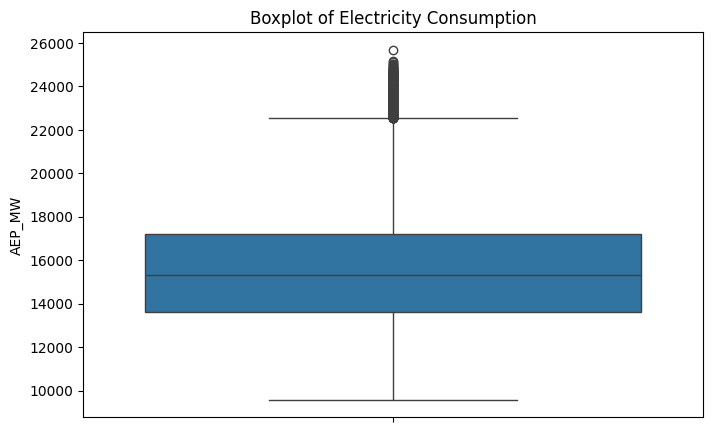

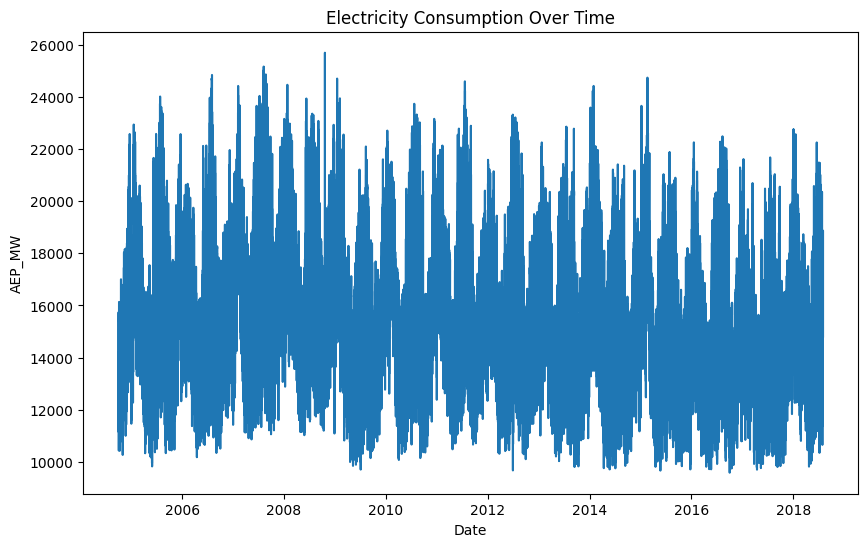

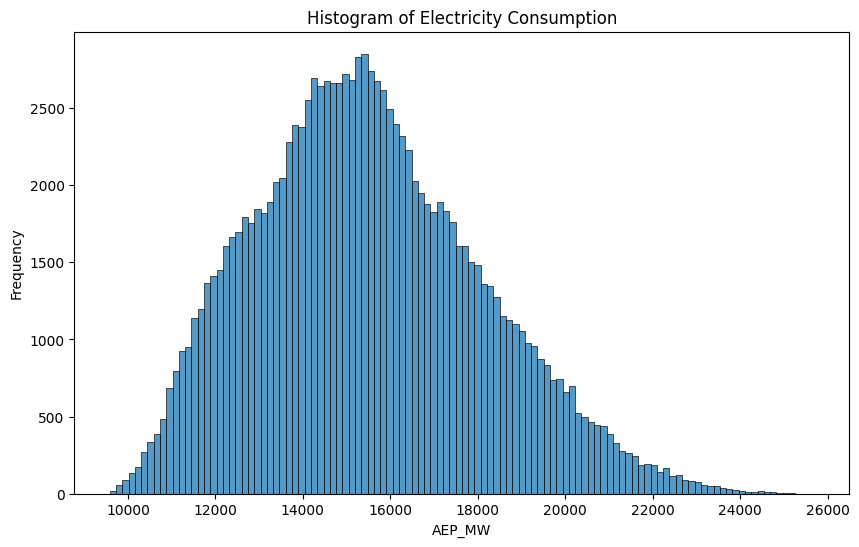

In [4]:
# missing values in AEP_MW for raw and cleaned data
print('missing values in AEP_MW for raw data:', df_raw['AEP_MW'].isna().sum())
print('missing values in AEP_MW for cleaned data:', df['AEP_MW'].isna().sum())

# percentrage of missing values
print('\npercentage of missing values in AEP_MW for raw data:', 100 * df_raw['AEP_MW'].isna().sum() / len(df_raw))
print('percentage of missing values in AEP_MW for cleaned data:', 100 * df['AEP_MW'].isna().sum() / len(df))

# filling missing values with linear interpolation
df['AEP_MW'] = df['AEP_MW'].interpolate(method='linear')
print('\nmissing values in AEP_MW for cleaned data after interpolation:', df['AEP_MW'].isna().sum())

# checking the data
display(df.describe())

# extreme/outliers
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['AEP_MW'])
plt.title('Boxplot of Electricity Consumption')
plt.ylabel('AEP_MW')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df.index, df['AEP_MW'])
plt.title('Electricity Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('AEP_MW')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(x=df['AEP_MW'])
plt.title('Histogram of Electricity Consumption')
plt.xlabel('AEP_MW')
plt.ylabel('Frequency')
plt.show()

Write your interpretation here:

- In the original data there were not missing values for the energy consumption, but there were missing timestamps.

- Counting them in, there is a very small missing data of about 0.022%.

- I used linear interpolation because the number of missing timestamps is very small and electricity demand usually changes gradually between neighboring hours.

- From inspecting the data, there aren't abnormal/impossible values, since all the data is around a possible number and there aren't negative values.

- As for extreme/outlier values, we can see from the boxplot that there is a tail, which we can clearly see from the other 2 plots, but as for energy consumption data, its expected and the values does not seem extreme.

---

# Part 4: Basic Statistical EDA

Calculate and explain the following statistics for the electricity consumption variable:

1. Mean
2. Median
3. Minimum
4. Maximum
5. Standard deviation
6. 25%, 50%, and 75% quantiles

Then answer:

1. Is the distribution symmetric or skewed?
2. Are there unusually high or low values?
3. What does the difference between the mean and median suggest?

In [5]:
display(df.describe())

,AEP_MW
count,121296.000000
mean,15499.150331
std,2591.379068
min,9581.000000
25%,13629.000000
50%,15309.000000
75%,17200.000000
max,25695.000000


Write your interpretation here:

- The distribution is slightly skewed to the right because the mean is slightly higher than the median (15499 vs 15309)

- There are no unusually low values and as for unusually high values, I don't think so, it seems pretty reasonable for there to be high demand during specific times and the data don't seem to go extremely high. So therefore I don't think there are unusually high or low values.

- The difference between the mean and median suggest skewness, since the mean is slightly higher than the median, it suggest a slightly right skewness but since they are very close, its mild.

---

# Part 5: Visualizing the Full Time Series

Create a line plot of the full time series.

Answer:

1. Can you identify long-term trends?
2. Are there repeated seasonal patterns?
3. Are there sudden drops or spikes?
4. Does the variance look constant over time?

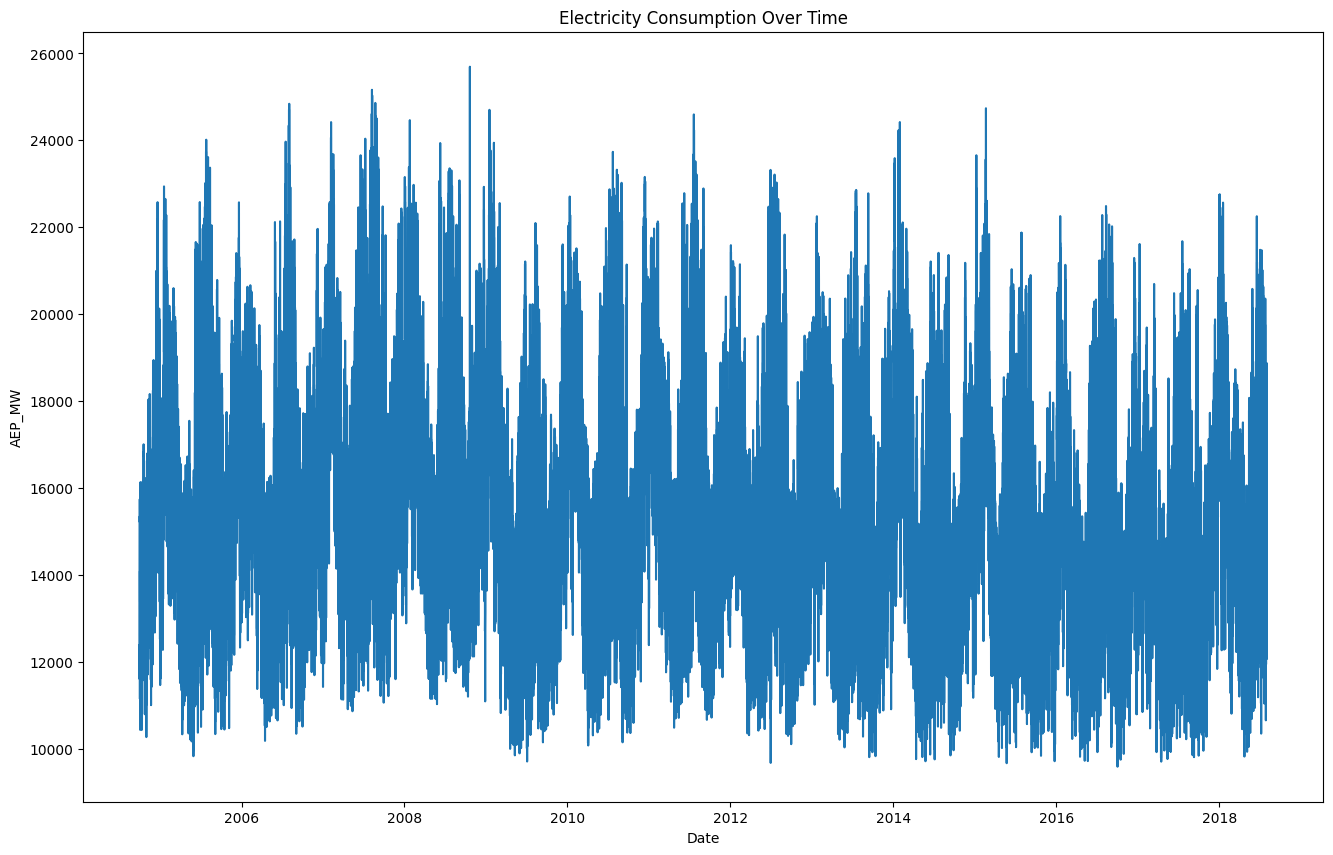

In [6]:
plt.figure(figsize=(16, 10))
plt.plot(df.index, df['AEP_MW'])
plt.title('Electricity Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('AEP_MW')
plt.show()

Write your interpretation here:

- From visualization, there seems to be a slight long term trend but its visually hard to see because the graph is noisy.

- As for repeated seasonal patterns, there is a seasonal pattern, we can see that over a year there are two increases and 2 decreases, probably because of the seasons, winter and summer require more energy consumption while autumn and spring require less.

- There are few sudden spikes and drops, but they dont seem too big and probably correspond to an extreme weather/holiday for spring and autumn or nice weather during winter and summer.

- The variance looks consistent across time, with maybe slight changes for some years but overall it looks the stable.

---

# Part 6: Zooming into Specific Time Windows

Select and plot:

1. One full year
2. One full month
3. One full week
4. One full day

Answer:

1. What patterns are easier to see when zooming in?
2. Is there a daily cycle?
3. Is there a weekly cycle?
4. Are weekends different from weekdays?

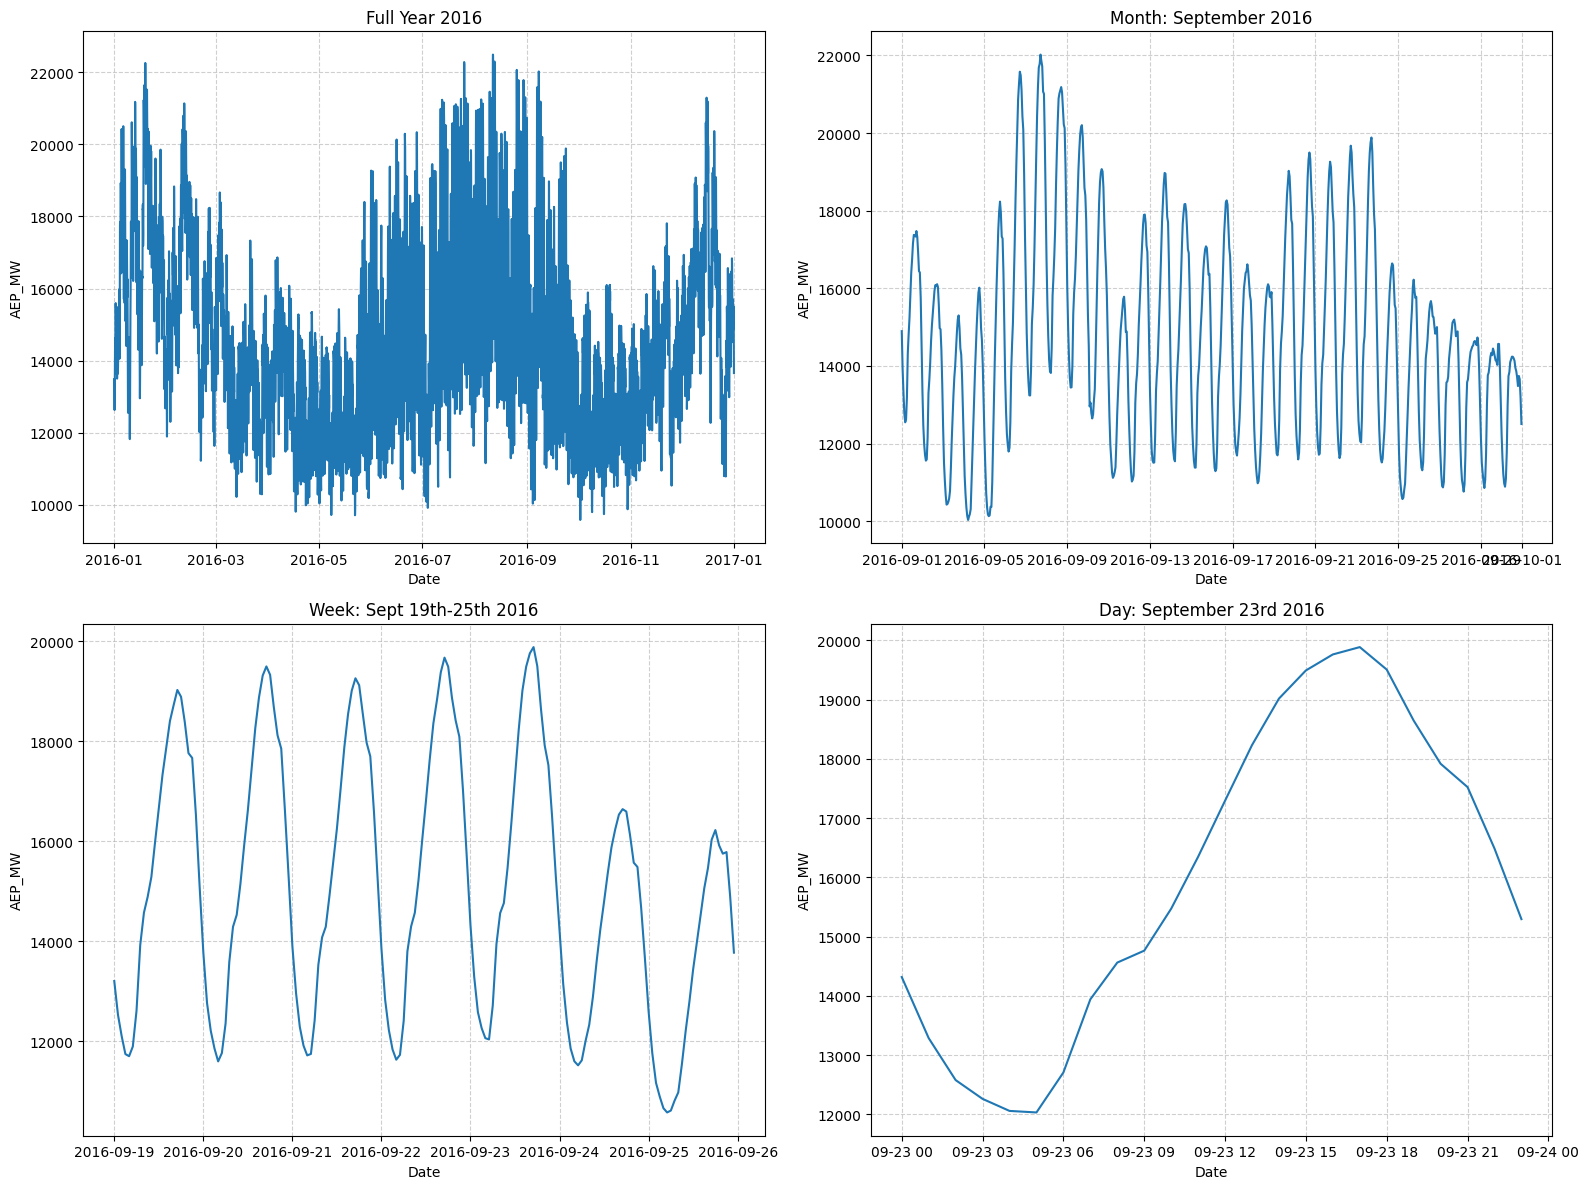

In [7]:
# defining the dates
plots = {
    "Full Year 2016": df['AEP_MW'].loc['2016'],
    "Month: September 2016": df['AEP_MW'].loc['2016-09'],
    "Week: Sept 19th-25th 2016": df['AEP_MW'].loc['2016-09-19':'2016-09-25'],
    "Day: September 23rd 2016": df['AEP_MW'].loc['2016-09-23']
}

# plotting
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, (title, data) in zip(axes.flatten(), plots.items()):
    ax.plot(data.index, data.values)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("AEP_MW")
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Write your interpretation here:

- As we zoom in, short term patterns are much clearer.

- There is a daily cycle, we can see that the night/early morning hours have lower energy consumption, while rises during the day and start to lower again at the evening.

- There is a weekly cycle, we see the daily pattern we talked about during all those days, but for the weekly cycle, we can see that there is a special time during the weekends where the energy consumption is smaller than the weekdays.

- Yes, weekends have lower energy consumption, specifically during the day since during the night there is a baseline usage, but during the day we see a sharp decrease but around the same cycle, while weekdays are mostly the same.

---

# Part 7: Resampling

Resample the hourly data into:

1. Daily average consumption
2. Weekly average consumption
3. Monthly average consumption

Create plots for each resampled series.

Answer:

1. What information is lost when resampling?
2. What information becomes easier to see?
3. Which resampling level is best for identifying long-term trends?
4. Which resampling level is best for identifying short-term behavior?

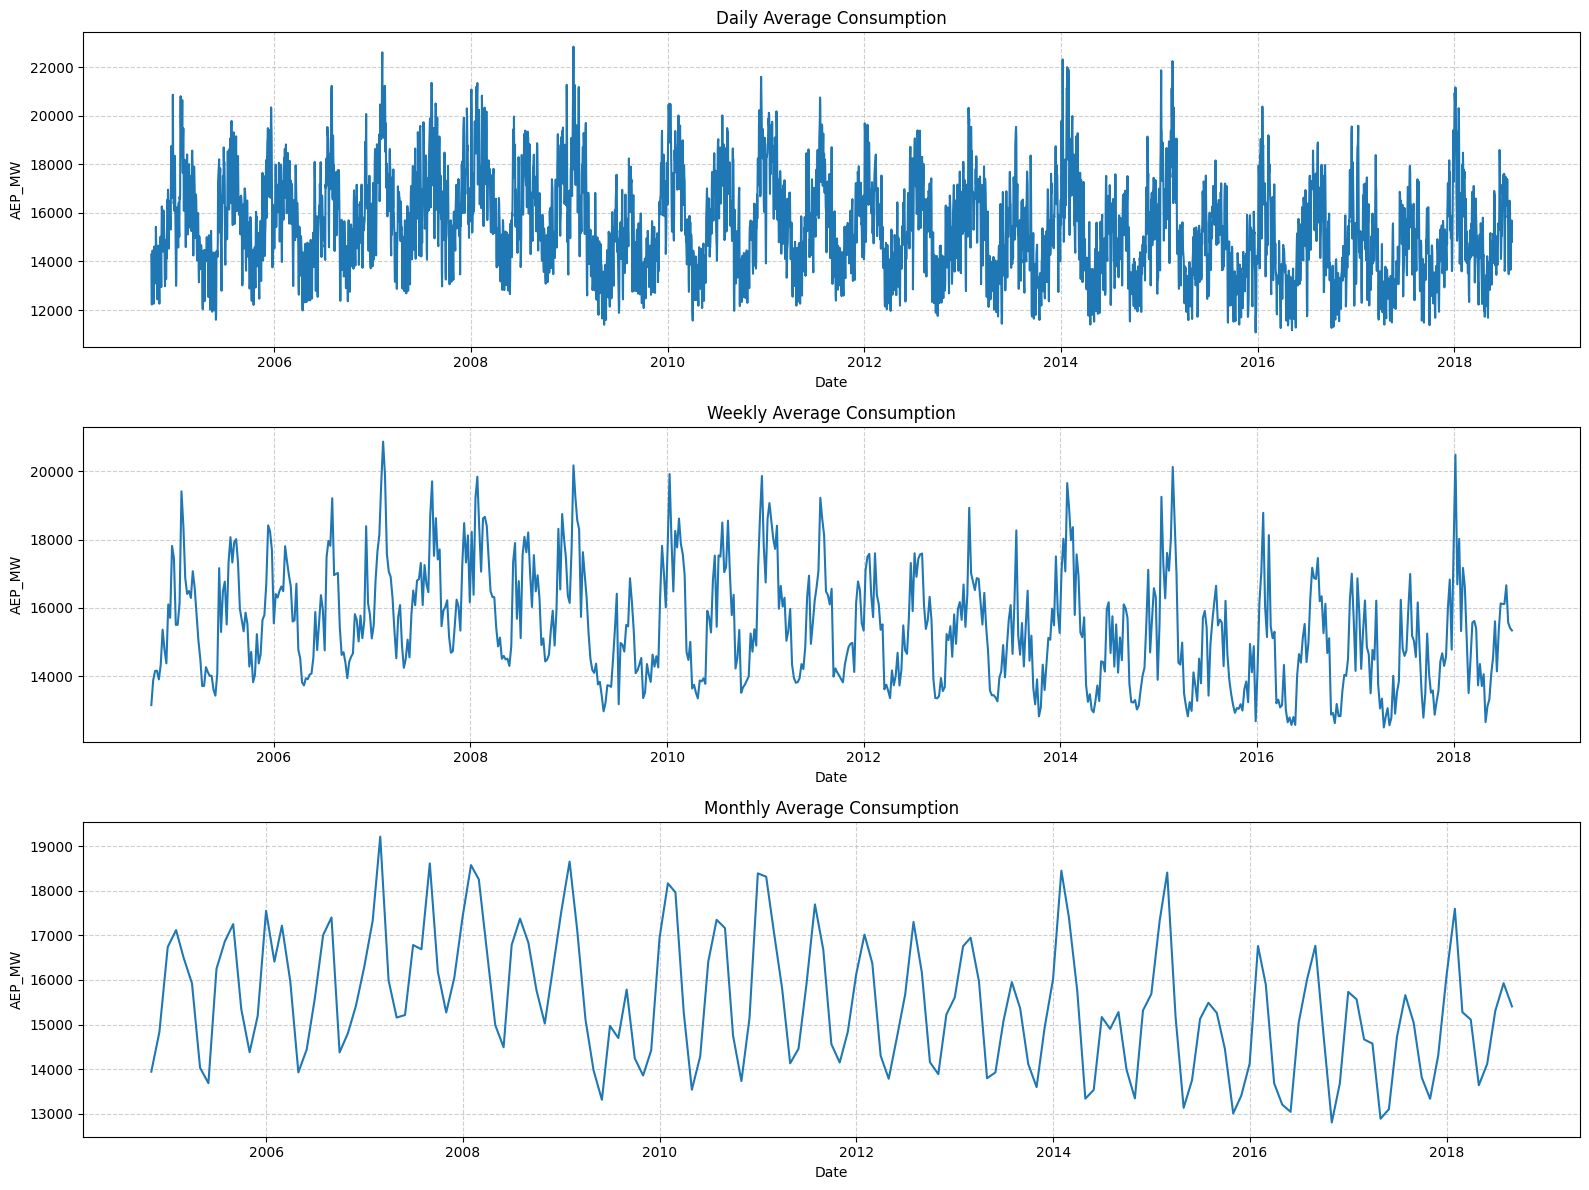

In [8]:
# defining the resamples
plots = {
    "Daily Average Consumption": df['AEP_MW'].resample("D").mean(),
    "Weekly Average Consumption": df['AEP_MW'].resample("W").mean(),
    "Monthly Average Consumption": df['AEP_MW'].resample("ME").mean()
}

# plotting
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for ax, (title, data) in zip(axes.flatten(), plots.items()):
    ax.plot(data.index, data.values)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("AEP_MW")
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Write your interpretation here:

- We lose the original resolution such as exact peaks, lows, and within-day patterns are lost for daily resampling, the bigger the resampling window, the more resolution we lose.

- Seasonal patterns and overall trends become easier to see because the data is smoother.

- Monthly resampling is best because it smooths short-term fluctuations the most and reduces noise.

- Daily resampling is best because it preserves more detail than weekly or monthly averages.

---

# Part 8: Seasonality Analysis

Create new time-based features:

1. Hour of day
2. Day of week
3. Month
4. Year

Then create the following plots:

1. Average consumption by hour of day
2. Average consumption by day of week
3. Average consumption by month
4. Average consumption by year

Answer:

1. During which hours is electricity consumption highest?
2. During which hours is it lowest?
3. Which days of the week have higher consumption?
4. Which months have higher consumption?
5. What seasonal patterns do you observe?

In [9]:
df['hour'] = pd.DatetimeIndex(df.index).hour
df['day_of_week'] = pd.DatetimeIndex(df.index).dayofweek
df['month'] = pd.DatetimeIndex(df.index).month
df['year'] = pd.DatetimeIndex(df.index).year

# grouping for plots
hour_avg = df.groupby('hour')['AEP_MW'].mean()
dow_avg = df.groupby('day_of_week')['AEP_MW'].mean()
month_avg = df.groupby('month')['AEP_MW'].mean()
year_avg = df.groupby('year')['AEP_MW'].mean()

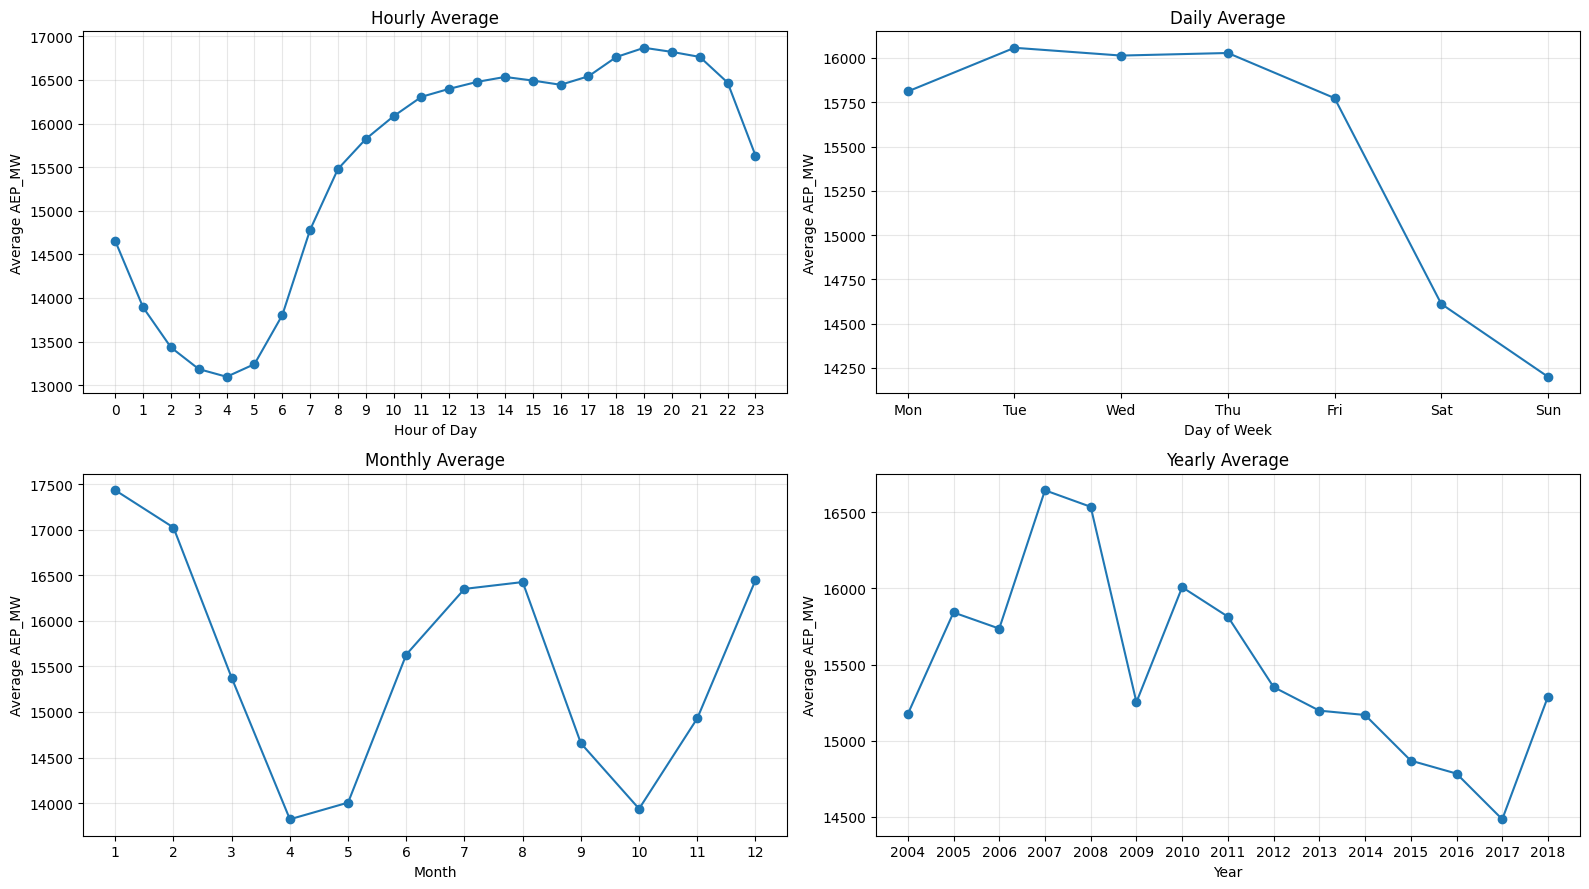

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Hourly average
hour_avg.plot(ax=axes[0, 0], marker='o')
axes[0, 0].set_title("Hourly Average")
axes[0, 0].set_xlabel("Hour of Day")
axes[0, 0].set_xticks(range(24))

# Daily average
dow_avg.plot(ax=axes[0, 1], marker='o')
axes[0, 1].set_title("Daily Average")
axes[0, 1].set_xlabel("Day of Week")
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

# Monthly average
month_avg.plot(ax=axes[1, 0], marker='o')
axes[1, 0].set_title("Monthly Average")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_xticks(range(1, 13))

# Yearly average
year_avg.plot(ax=axes[1, 1], marker='o')
axes[1, 1].set_title("Yearly Average")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_xticks(year_avg.index)

for ax in axes.ravel():
    ax.set_ylabel("Average AEP_MW")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Write your interpretation here:

- Consumption is highest in the evening, especially around 18:00–21:00, with the peak around 19:00.

- Consumption is lowest overnight and early morning, especially around 03:00–05:00.

- Weekdays have higher consumption, especially Tuesday, Wednesday, and Thursday.

- Consumption is higher in January, February, July, August, and December, which correspond to the winter and summer months.

- I see seasonality at multiple levels: consumption rises during the day and peaks in the evening, is higher on weekdays than weekends, and is highest in winter and summer months while lower in spring and autumn.

- The yearly averages for 2004 and 2018 should be interpreted carefully because these are partial years in the dataset.

---

# Part 9: Distribution Analysis

Create:

1. Histogram of electricity consumption
2. Boxplot of electricity consumption
3. Boxplot by hour
4. Boxplot by month

Answer:

1. Is the distribution normal?
2. Are there many outliers?
3. Which hours have the largest variability?
4. Which months have the largest variability?

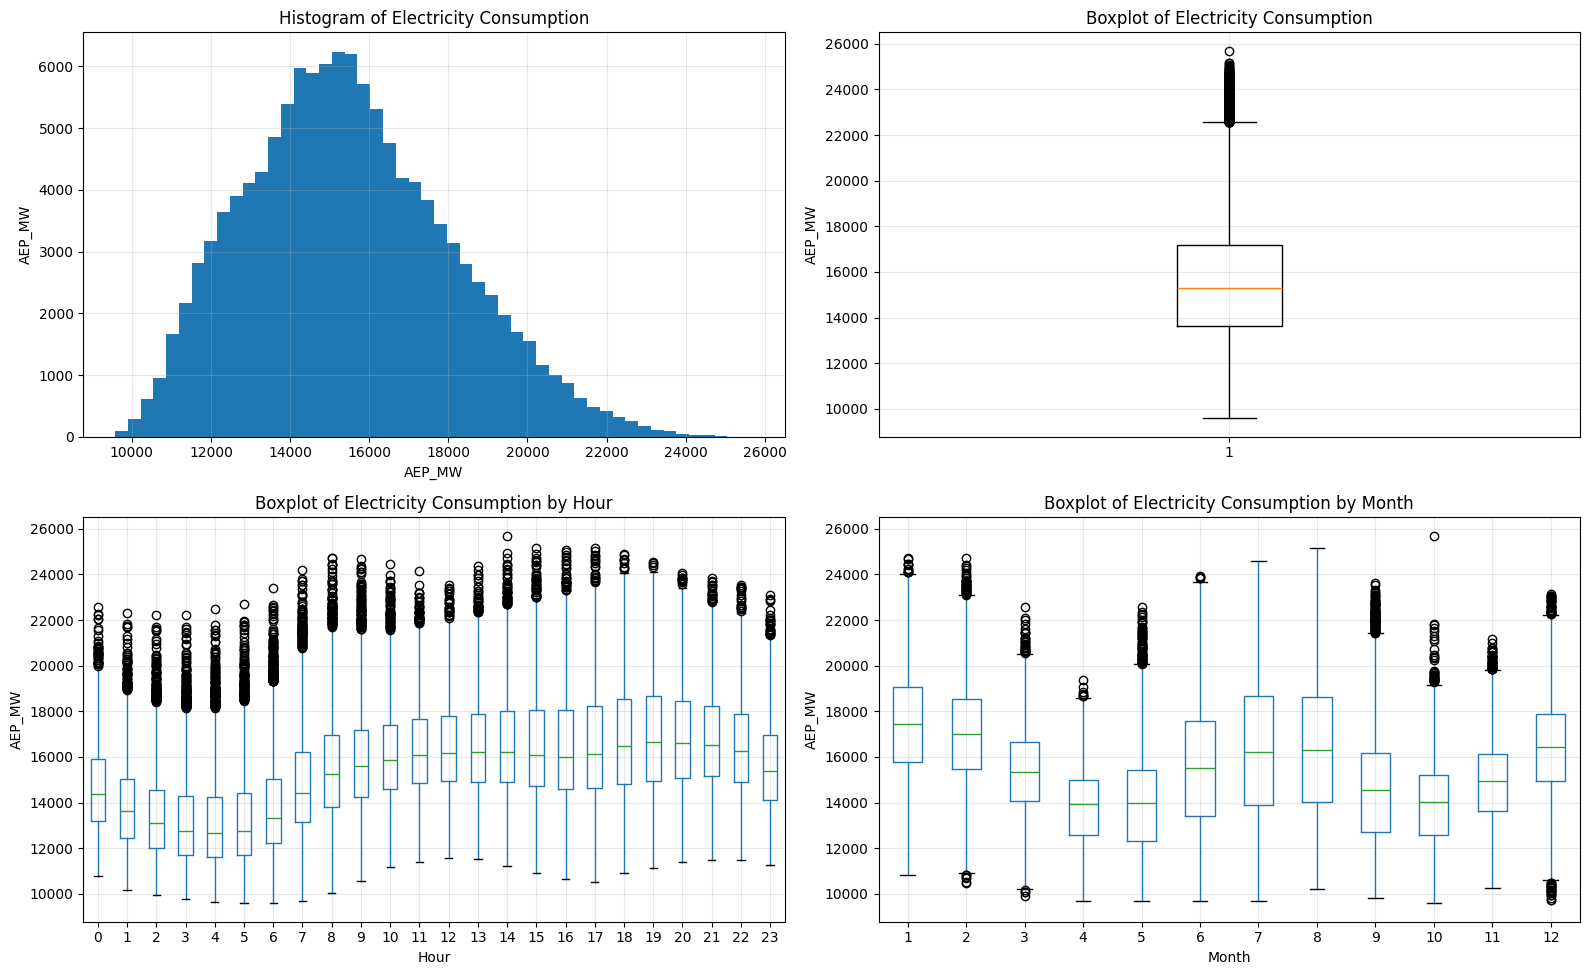

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# histogram
axes[0, 0].hist(df['AEP_MW'], bins=50)
axes[0, 0].set_title("Histogram of Electricity Consumption")
axes[0, 0].set_xlabel("AEP_MW")

# boxplot
axes[0, 1].boxplot(df['AEP_MW'])
axes[0, 1].set_title("Boxplot of Electricity Consumption")

# boxplot by hour
df.boxplot(column='AEP_MW', by='hour', ax=axes[1, 0])
axes[1, 0].set_title("Boxplot of Electricity Consumption by Hour")
axes[1, 0].set_xlabel("Hour")

# boxplot by month
df.boxplot(column='AEP_MW', by='month', ax=axes[1, 1])
axes[1, 1].set_title("Boxplot of Electricity Consumption by Month")
axes[1, 1].set_xlabel("Month")

for ax in axes.ravel():
    ax.set_ylabel("AEP_MW")
    ax.grid(True, alpha=0.3)

plt.suptitle("")
plt.tight_layout()
plt.show()

Write your interpretation here:

- The distribution is not normal, it is slightly right-skewed with a long high-consumption tail.

- The boxplot shows high-consumption potential outliers, these high values may also represent real peak demand since real-world energy consumption can vary.

- The largest hourly variability is during late afternoon and evening hours, from the boxplot by hour its especially noticeable between 15:00-20:00.

- The largest monthly variability is during summer, especially July and August, while June also shows relatively high variability.

---

# Part 10: Autocorrelation

Plot the autocorrelation of the electricity consumption series.

Answer:

1. Is the series autocorrelated?
2. Do nearby observations depend on each other?
3. Can you identify daily seasonality?
4. Can you identify weekly seasonality?
5. Why is autocorrelation important for time series forecasting?

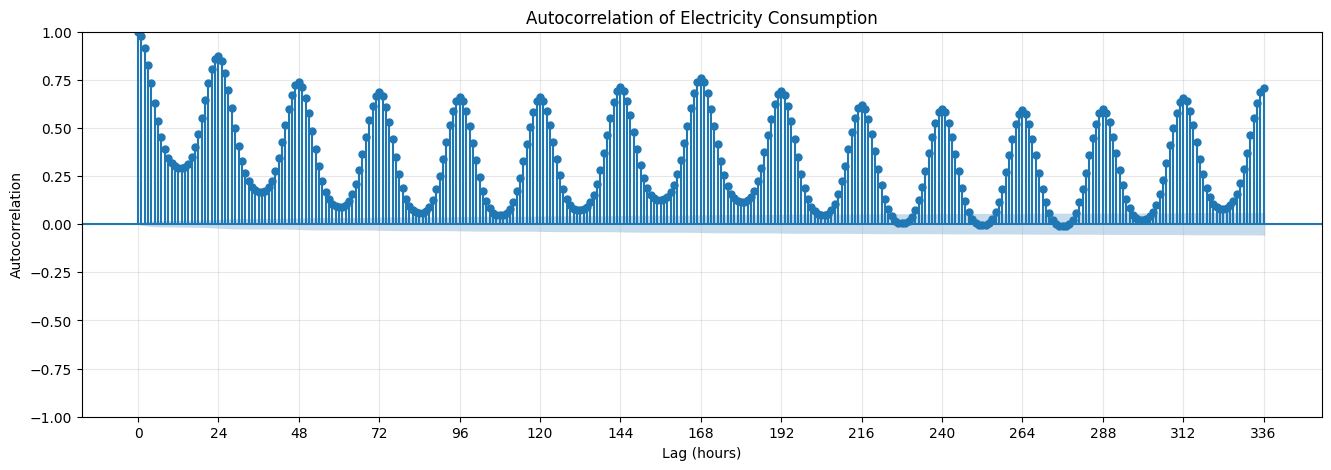

In [12]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(16, 5))

plot_acf(df['AEP_MW'], lags=24*14, ax=ax)

ax.set_xlabel('Lag (hours)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Autocorrelation of Electricity Consumption')
ax.set_xticks(range(0, 24*14 + 1, 24))
ax.grid(alpha=0.3)

plt.show()

Write your interpretation here:

- I used plot_acf with lags up to 24x14 hours to catch both daily and weekly seasonality, as well as correlation between nearby observations.

- The series is autocorrelated because many autocorrelation values are clearly above zero.

- Yes, nearby observations depend on each other because the autocorrelation is very high at small lags close to zero.

- Yes, we can see daily seasonality because there are repeated peaks every 24 hours, and the autocorrelation at lag 24 is high.

- Yes, we can see strong peak at around 168 hours and 336 hours, which shows that there is a weekly seasonality.

- Autocorrelation is important for time series forecasting because it shows that past values can help predict future values.

---

# Part 11: Stationarity Test

Use the Augmented Dickey-Fuller test.

Answer:

1. What is the null hypothesis of the ADF test?
2. What is the p-value?
3. Is the time series stationary?
4. Why does stationarity matter in time series analysis?
5. What transformations could make the series more stationary?

In [13]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df['AEP_MW'])

print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print("Number of lags used:", adf_result[2])
print("Number of observations used:", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -18.24651680240032
p-value: 2.348284386458477e-30
Number of lags used: 71
Number of observations used: 121224

Critical Values:
1%: -3.4304039450808115
5%: -2.8615638429265644
10%: -2.5667826907474756


Write your interpretation here:

- The null hypothesis of the ADF test is that the series has a unit root, which means the series is non-stationary.

- The p-value says that assuming the null hypothesis, how surprised are we to see the result. Here we got p-value = 2.3e-30, meaning we reject the null hypothesis since the p-value is much lower than 0.05.

- According to the ADF test, we reject the null hypothesis, so the series appears stationary under this test. However, from the plots we clearly see seasonal patterns, so this result should be interpreted carefully.

- Stationarity matters in time series analysis because many models assume statistical properties remain stable across time like mean, variance and autocorrelation. That is because if they don't, learned patterns change and the forecasting may be unreliable in the situation of non-stationarity.

- This can be done by decomposing the series and removing trend and seasonal components. The Methods include moving averages, LOESS, period-adjusted averages, Fourier terms, STL, or MSTL decomposition.

---

# Part 12: Rolling Statistics

Calculate and plot:

1. 24-hour rolling mean
2. 7-day rolling mean
3. 30-day rolling mean
4. 24-hour rolling standard deviation

Answer:

1. What does the rolling mean reveal?
2. What does the rolling standard deviation reveal?
3. Does the variability change over time?
4. Are there periods with unusually high or low demand?

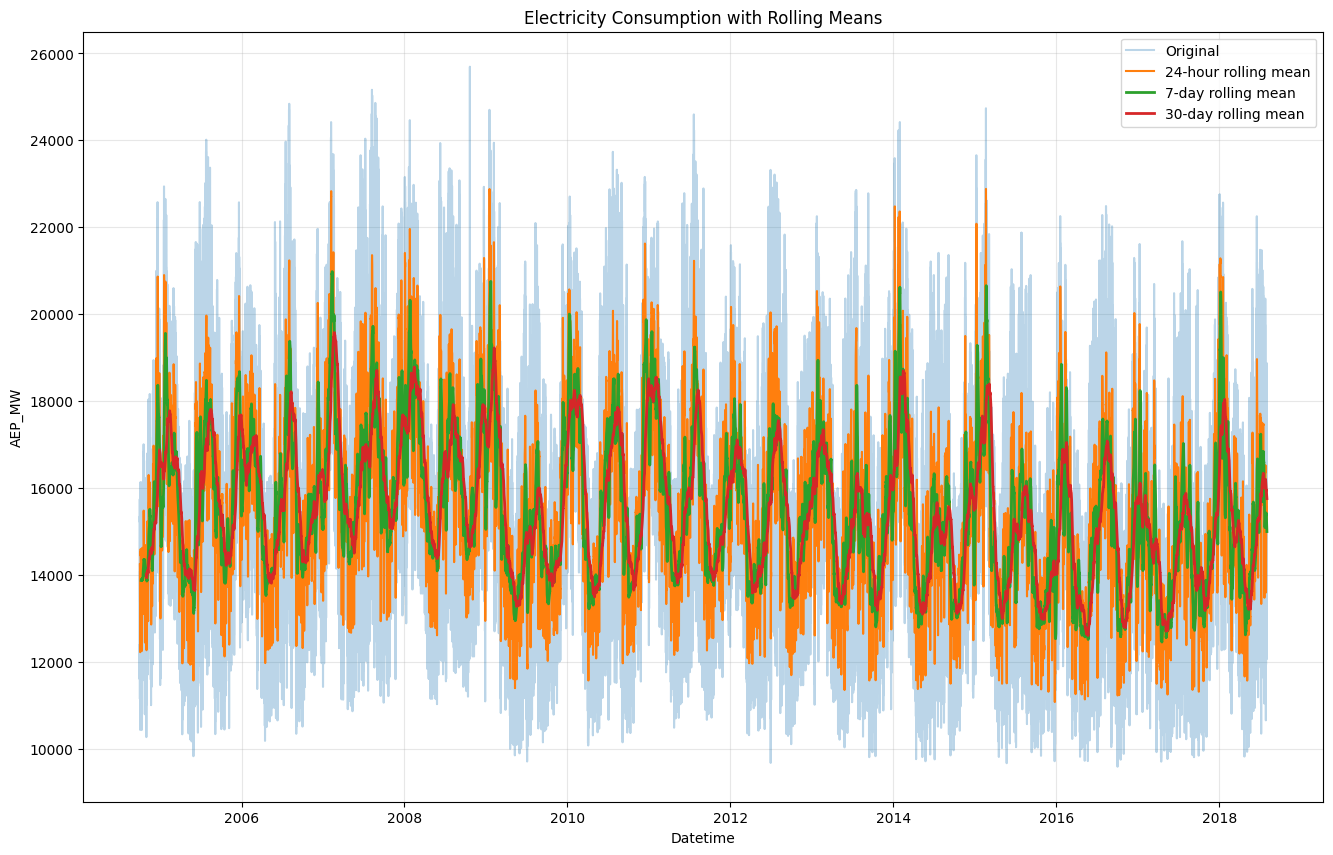

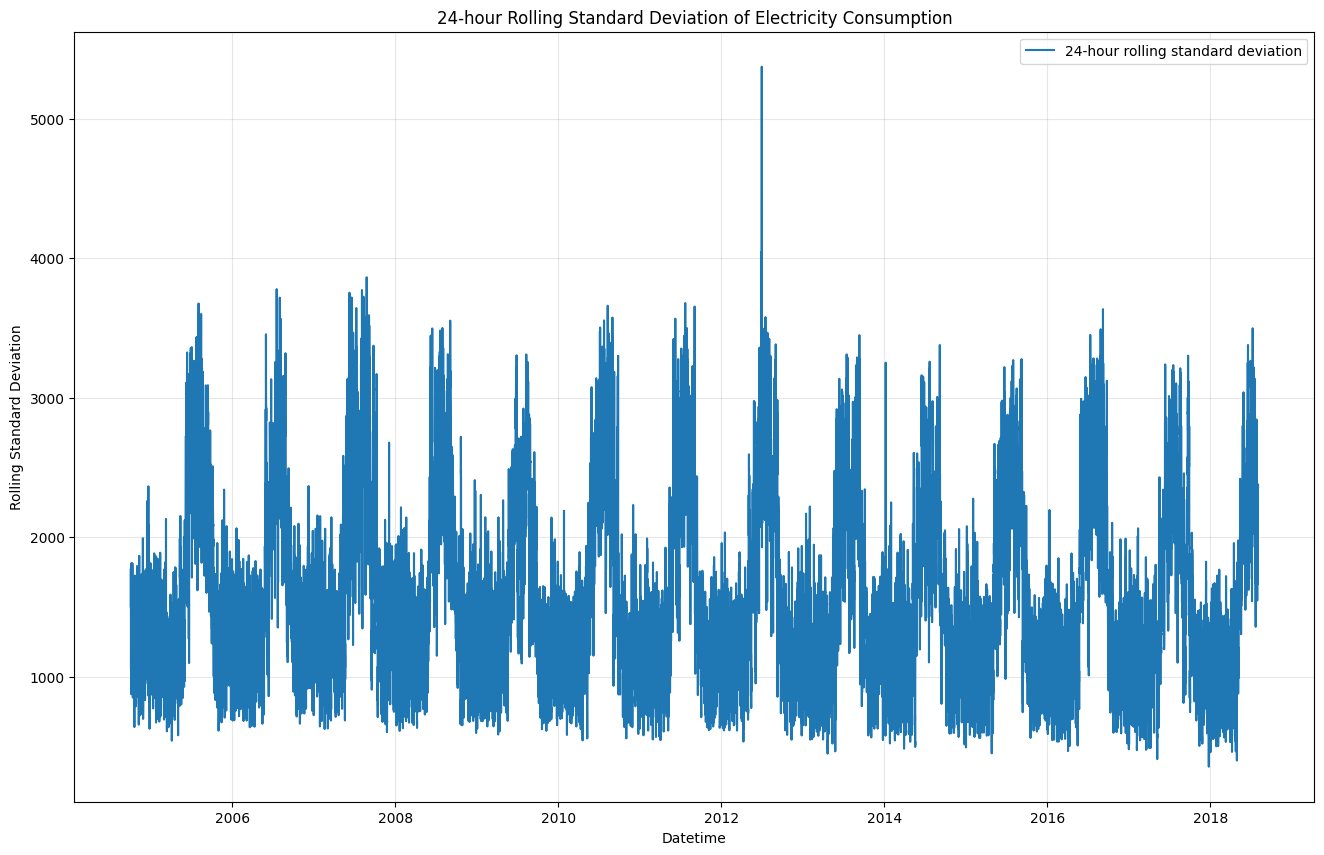

In [14]:
# rolling statistics
rolling_24h_mean = df['AEP_MW'].rolling(window=24).mean()
rolling_7d_mean = df['AEP_MW'].rolling(window=24*7).mean()
rolling_30d_mean = df['AEP_MW'].rolling(window=24*30).mean()
rolling_24h_std = df['AEP_MW'].rolling(window=24).std()

# plots rolling means
plt.figure(figsize=(16, 10))

plt.plot(df['AEP_MW'], label='Original', alpha=0.3)
plt.plot(rolling_24h_mean, label='24-hour rolling mean', linewidth=1.5)
plt.plot(rolling_7d_mean, label='7-day rolling mean', linewidth=2)
plt.plot(rolling_30d_mean, label='30-day rolling mean', linewidth=2)

plt.title('Electricity Consumption with Rolling Means')
plt.xlabel('Datetime')
plt.ylabel('AEP_MW')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Plot rolling standard deviation
plt.figure(figsize=(16, 10))

plt.plot(rolling_24h_std, label='24-hour rolling standard deviation')

plt.title('24-hour Rolling Standard Deviation of Electricity Consumption')
plt.xlabel('Datetime')
plt.ylabel('Rolling Standard Deviation')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Write your interpretation here:

- The rolling mean smooths short-term changes, reduces noise, and makes the long-term pattern more visible. Different window sizes change the smoothness: a 24-hour window keeps some short-term changes, while 7-day and 30-day windows reveal broader patterns.

- The rolling standard deviation reveals the local variability of the time series within each time window. In this case, it helps show periods where electricity demand is more volatile, compared to periods where demand is relatively stable.

- The variability changes over time and follows a yearly seasonal pattern. This shows that the series does not have perfectly constant variance, even though the pattern is somewhat regular and repeats across years.

- There are no clear unusually high or low periods that look like anomalies. Instead, the high and low demand periods seem to repeat yearly, suggesting regular seasonality.

---

# Part 13: Decomposition

Use seasonal decomposition on a daily or monthly resampled series.

Answer:

1. What does the trend component show?
2. What does the seasonal component show?
3. What does the residual component show?
4. Does an additive decomposition seem appropriate?
5. Would a multiplicative decomposition be better? Explain.

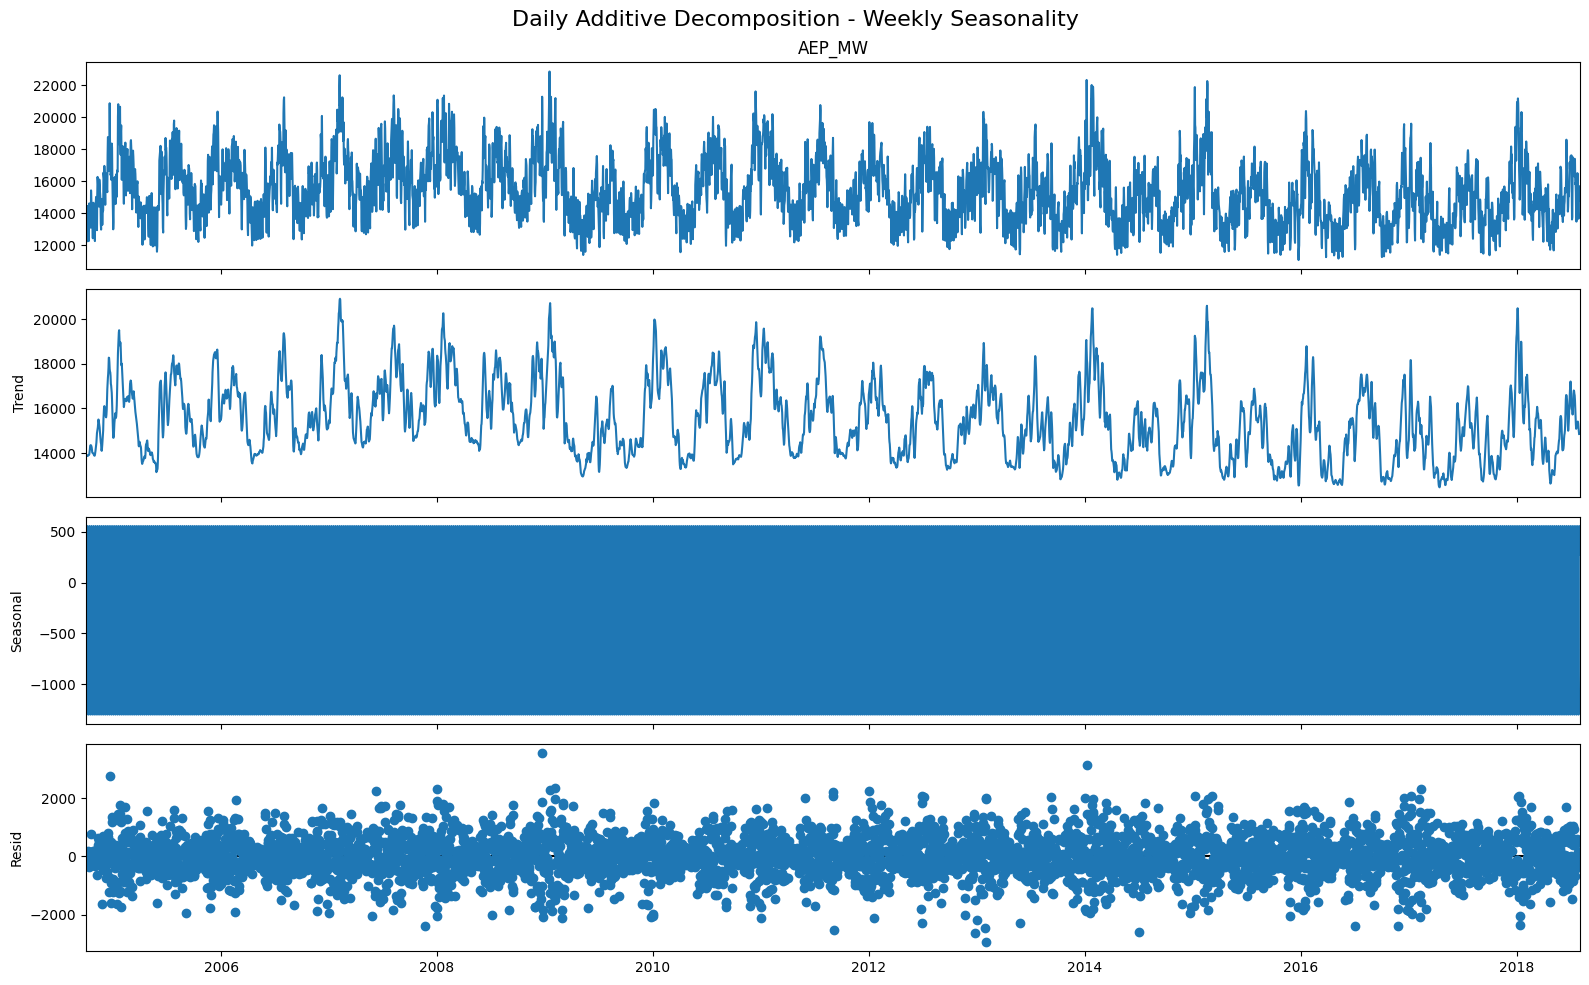

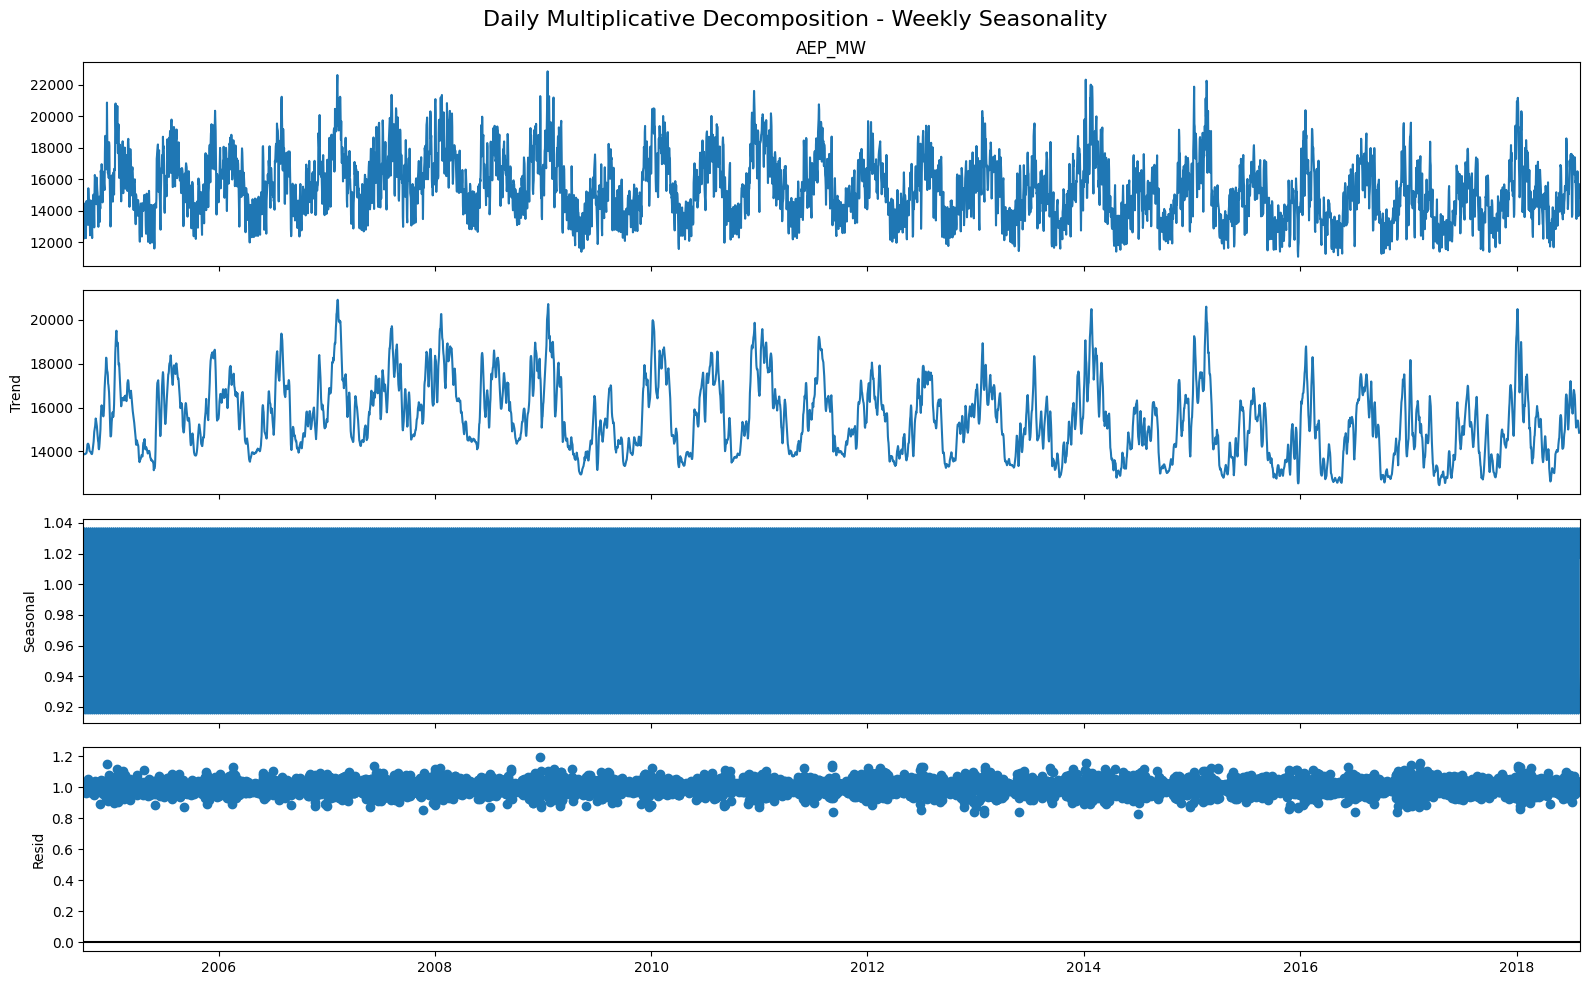

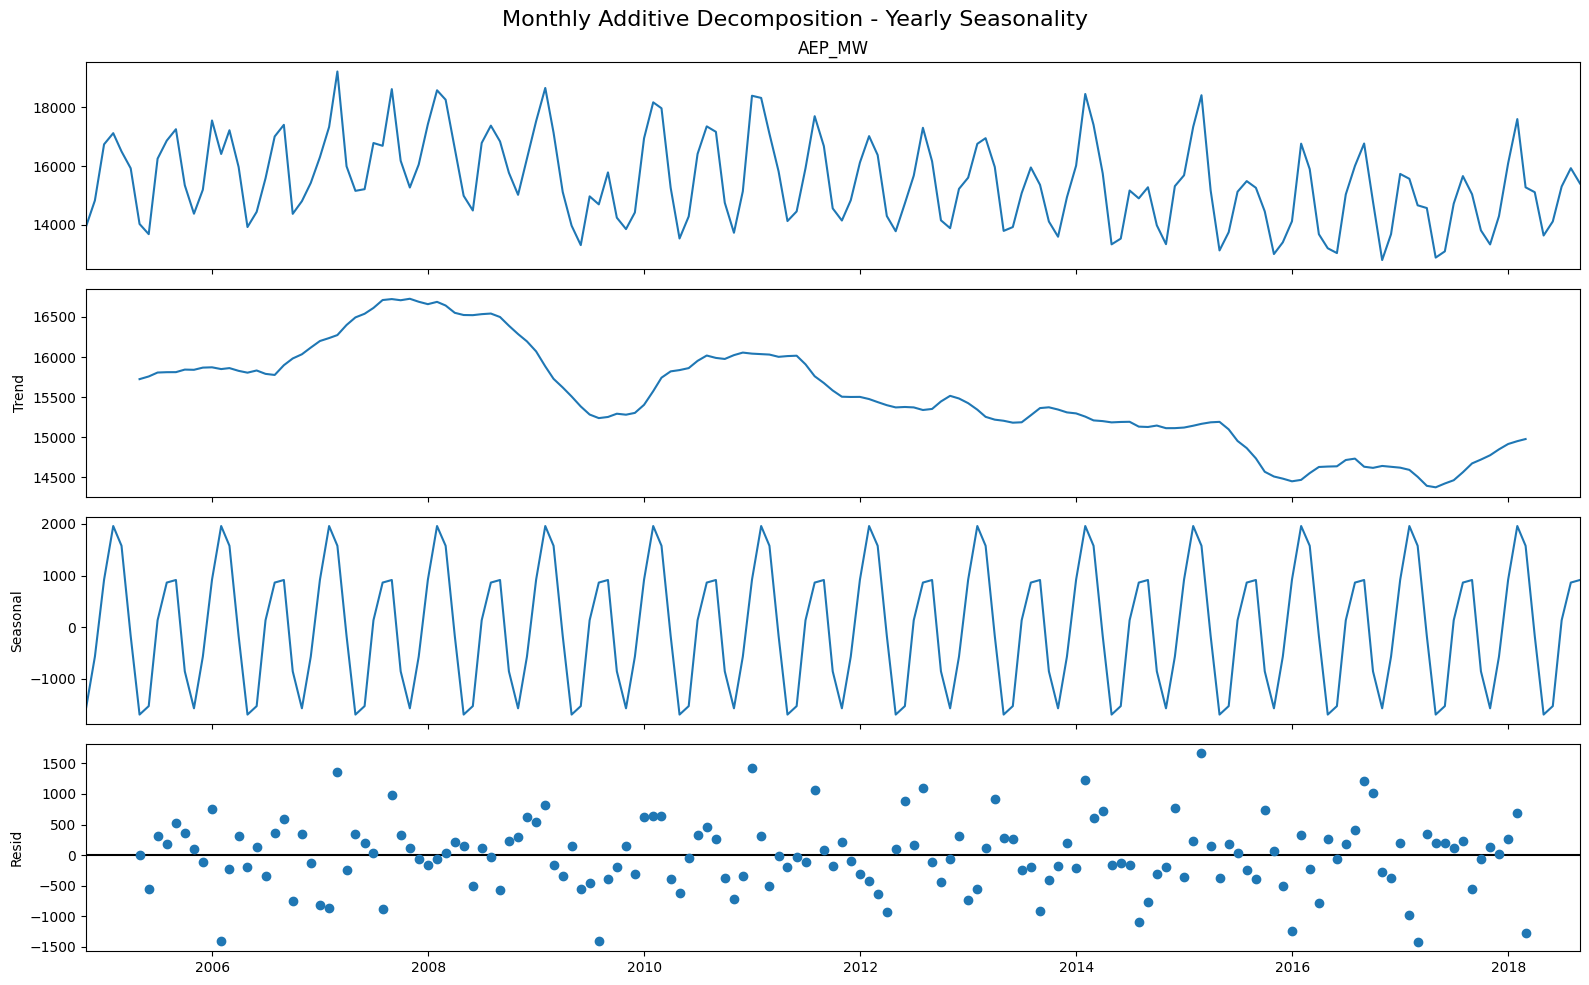

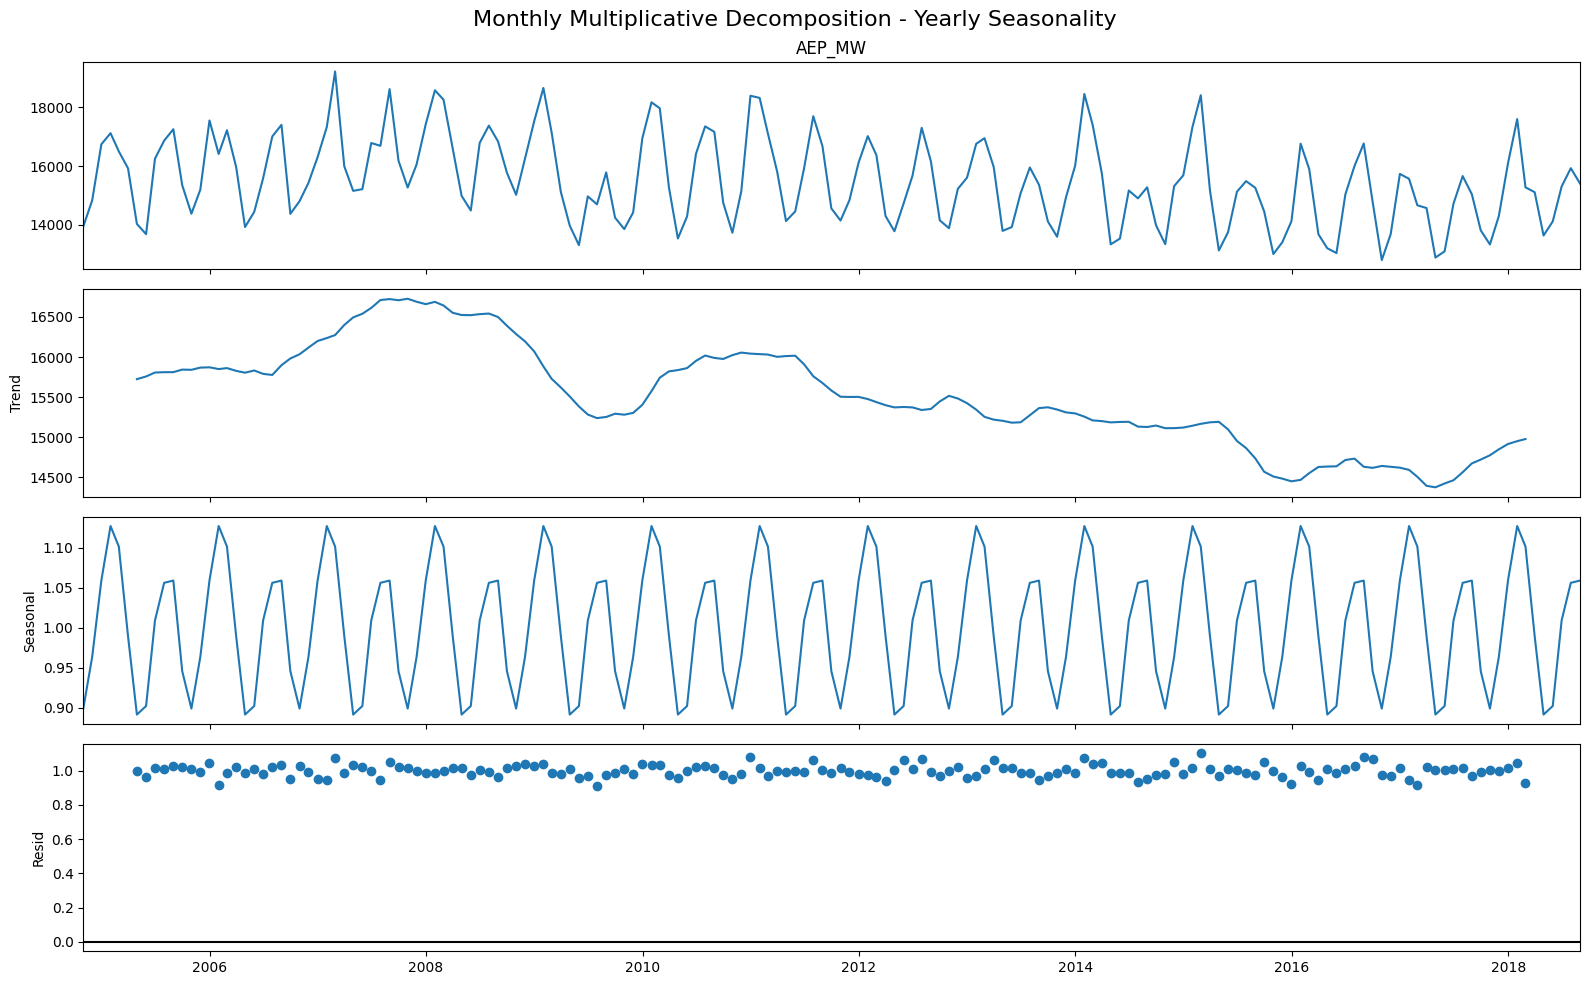

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily_series = df['AEP_MW'].resample('D').mean()
monthly_series = df['AEP_MW'].resample('ME').mean()

decomposition_daily_add = seasonal_decompose(daily_series, model="additive", period=7)
fig = decomposition_daily_add.plot()
fig.set_size_inches(16, 10)
fig.suptitle("Daily Additive Decomposition - Weekly Seasonality", fontsize=16)
plt.tight_layout()
plt.show()

decomposition_daily_mul = seasonal_decompose(daily_series, model="multiplicative", period=7)
fig = decomposition_daily_mul.plot()
fig.set_size_inches(16, 10)
fig.suptitle("Daily Multiplicative Decomposition - Weekly Seasonality", fontsize=16)
plt.tight_layout()
plt.show()

decomposition_monthly_add = seasonal_decompose(monthly_series, model="additive", period=12)
fig = decomposition_monthly_add.plot()
fig.set_size_inches(16, 10)
fig.suptitle("Monthly Additive Decomposition - Yearly Seasonality", fontsize=16)
plt.tight_layout()
plt.show()

decomposition_monthly_mul = seasonal_decompose(monthly_series, model="multiplicative", period=12)
fig = decomposition_monthly_mul.plot()
fig.set_size_inches(16, 10)
fig.suptitle("Monthly Multiplicative Decomposition - Yearly Seasonality", fontsize=16)
plt.tight_layout()
plt.show()

Write your interpretation here:

- The trend component shows the smoothed long-term movement of electricity demand. In the daily decomposition, it shows longer-term changes after removing weekly seasonality, while in the monthly decomposition it shows the broader pattern after accounting for yearly seasonality.

- The seasonal component shows the repeating pattern captured by the chosen period. In the daily decomposition, period 7 captures weekly seasonality, while in the monthly decomposition, period 12 captures yearly seasonality.

- The residual component shows the part of the series that is not explained by the trend or seasonal components.

- An additive decomposition seems appropriate because the seasonal changes appear to be roughly fixed amounts rather than clearly proportional to the level of the series. In the additive model, the seasonal component is measured in MW, making it easier to interpret how much demand is added or subtracted from the trend.

- I do not think the multiplicative decomposition is better here, because it is harder to interpret. The additive decomposition shows the seasonal effect directly in MW, while the multiplicative decomposition shows it as a proportional factor. Since the seasonal changes appear reasonably stable in size, the additive decomposition is more appropriate and easier to explain.

---

# Part 14: Summary and Conclusions

Write a short EDA report, about 1-2 pages, that includes:

1. Description of the dataset
2. Time range and frequency
3. Missing values and data quality issues
4. Main trends
5. Main seasonal patterns
6. Distribution and outliers
7. Autocorrelation findings
8. Stationarity test conclusion
9. Recommendations for preprocessing before forecasting

## Final EDA Report

### Dataset Description

The dataset contains hourly electricity demand in the AEP region over time. The main variable is AEP_MW, which represents electricity demand measured in megawatts. Each value is associated with a timestamp from the Datetime column, which represents when the observation was recorded.

### Time Range and Frequency

The data spans from October 2004 to August 2018, with an hourly frequency. This gives almost 14 years of hourly electricity demand observations.

### Missing Values and Data Quality

The dataset contains 121,273 original entries. There are 4 unique duplicated timestamps and 27 missing hourly timestamps after creating a complete hourly index.  

The missing timestamps represent about 0.022% of the data, so the amount of missing data is very small. I filled these missing timestamps using linear interpolation because electricity demand usually changes smoothly between neighboring hours. For duplicated timestamps, I used the mean value for each duplicated timestamp.  

There are no missing values apart from the missing timestamps, and there are no impossible values such as negative electricity demand. Some high values appear in the data, but they do not seem unusual for electricity demand and are likely related to peak demand periods rather than data errors.

### Trends and Seasonality

The series shows several clear seasonal patterns. There is a daily pattern by hour of day: electricity demand is lowest during the night and early morning, then increases during the daytime and evening before decreasing again.

There is also a weekly pattern by day of week. Demand is relatively steady during weekdays from Monday to Friday, while weekends show a noticeable decline. On the monthly level, demand is higher during winter and summer and lower during spring and autumn, which suggests yearly seasonality.

As for the long-term trend, electricity demand appears broadly stable with a slight downward tendency across the years. However, the seasonal patterns are much more noticeable than the long-term trend.

### Distribution and Outliers

The distribution is not normally distributed and appears slightly right-skewed, with a longer tail toward higher electricity demand. Most values are concentrated around the central demand range, while fewer observations appear at very high demand levels.

The boxplot shows some potential high-end outliers, but these should not automatically be treated as data errors. Since electricity demand naturally increases during peak hours and high-demand seasons, these values are likely related to real peak demand periods. Therefore, I would investigate them further rather than remove them automatically.

### Autocorrelation and Stationarity

The ACF plot shows strong autocorrelation, especially for neighboring values and at lags around 24 hours and 168 hours. This suggests strong persistence, daily seasonality, and weekly seasonality.

According to the ADF test, we reject the null hypothesis of a unit root, so the series appears stationary under this test. However, this result should be interpreted carefully. The visual analysis and ACF plot show strong daily, weekly, and yearly seasonal patterns, so the raw series is not perfectly stationary in a practical sense.

### Recommendations Before Forecasting

Before forecasting, I would use the cleaned data with the regular hourly time index, including the interpolated missing timestamps and averaged duplicated timestamps.

The forecasting model should account for daily, weekly, and yearly seasonality, since these patterns are clearly visible in the EDA. This can be done using seasonal features, decomposition, or models that explicitly handle seasonality.

Statistical outliers should not be removed automatically, because high demand values may represent real peak demand periods. The train/test split should also be based on time rather than a random split, so the model is trained on past observations and evaluated on future observations.

---

# Optional Extension - Bonus

Students who want an additional challenge may compare the AEP series with another electricity region from the same Kaggle dataset.

Compare:

1. Mean consumption
2. Seasonal patterns
3. Autocorrelation
4. Stationarity
5. Volatility over time

---

# Submission Instructions

Submit:

1. A Jupyter Notebook with all code, plots, and explanations.
2. A short written summary at the end of the notebook.
3. The notebook should be clean, organized, and divided into sections.
4. All plots must include titles and axis labels.
5. Every major result should be followed by a short explanation.